# Phishing URL Detection — Hybrid ML + Deep Learning

This notebook demonstrates:

• Random Forest baseline model  
• BiLSTM deep learning model  
• Fusion ensemble model  
• Cross-dataset benchmarking  
• Reproducible evaluation pipeline

Dataset: StealthPhisher + Kaggle Balanced URLs


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'songs', 'IMG20230709173734.jpg', 'IMG20230709173708.jpg', 'IMG20230709173706.jpg', 'IMG20230709173441.jpg', 'IMG20230709173442.jpg', 'IMG20230709173437.jpg', 'IMG20230709165748.jpg', 'IMG20230709165747.jpg', 'VID20230709165636.mp4', 'VID20230709172215.mp4', 'VID20230709165230.mp4', 'IMG20230709165016.jpg', 'IMG20230709165009.jpg', 'IMG20230709165007.jpg', 'IMG20230709165005.jpg', 'IMG20230709164911.jpg', 'VID20230709153807.mp4', 'IMG20230709154432.jpg', 'IMG20230709152515.jpg', 'IMG20230709152513.jpg', 'IMG20230709152512.jpg', 'IMG20230709153647.jpg', 'IMG20230709151703.jpg', 'IMG20230709151659_01.jpg', 'IMG20230709151659.jpg', 'IMG20230709152202.jpg', 'IMG20230709152205.jpg', 'VID20230709151835.mp4', 'IMG20230709151832.jpg', 'IMG20230709151658.jpg', 'IMG20230709151649.jpg', 'IMG20230709151600.jpg', 'IMG20230709151554.jpg', 'IMG20230709151553.jpg', 'IMG20230709151538.jpg', 'IMG20230709151537.jpg', 'IMG20230709151536.jpg', 'IMG20230709151256.jpg', 'IMG20230709151254

In [5]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'songs',
 'IMG20230709173734.jpg',
 'IMG20230709173708.jpg',
 'IMG20230709173706.jpg',
 'IMG20230709173441.jpg',
 'IMG20230709173442.jpg',
 'IMG20230709173437.jpg',
 'IMG20230709165748.jpg',
 'IMG20230709165747.jpg',
 'VID20230709165636.mp4',
 'VID20230709172215.mp4',
 'VID20230709165230.mp4',
 'IMG20230709165016.jpg',
 'IMG20230709165009.jpg',
 'IMG20230709165007.jpg',
 'IMG20230709165005.jpg',
 'IMG20230709164911.jpg',
 'VID20230709153807.mp4',
 'IMG20230709154432.jpg',
 'IMG20230709152515.jpg',
 'IMG20230709152513.jpg',
 'IMG20230709152512.jpg',
 'IMG20230709153647.jpg',
 'IMG20230709151703.jpg',
 'IMG20230709151659_01.jpg',
 'IMG20230709151659.jpg',
 'IMG20230709152202.jpg',
 'IMG20230709152205.jpg',
 'VID20230709151835.mp4',
 'IMG20230709151832.jpg',
 'IMG20230709151658.jpg',
 'IMG20230709151649.jpg',
 'IMG20230709151600.jpg',
 'IMG20230709151554.jpg',
 'IMG20230709151553.jpg',
 'IMG20230709151538.jpg',
 'IMG20230709151537.jpg',
 'IMG20230709151536.jpg',
 'IMG

In [6]:
!unzip /content/drive/MyDrive/PhishingProject.zip -d /content

Archive:  /content/drive/MyDrive/PhishingProject.zip
   creating: /content/PhishingProject/
  inflating: /content/PhishingProject/benchmark_split.py  
  inflating: /content/PhishingProject/benchmark_test.csv  
  inflating: /content/PhishingProject/benchmark_test_idx.npy  
  inflating: /content/PhishingProject/benchmark_train.csv  
  inflating: /content/PhishingProject/benchmark_train_idx.npy  
  inflating: /content/PhishingProject/bilstm_benchmark.py  
  inflating: /content/PhishingProject/bilstm_model.pt  
  inflating: /content/PhishingProject/bilstm_preds.npy  
  inflating: /content/PhishingProject/bilstm_true.npy  
  inflating: /content/PhishingProject/cross_eval.py  
   creating: /content/PhishingProject/datasets/
  inflating: /content/PhishingProject/datasets/KaggleBalancedURLs.csv  
  inflating: /content/PhishingProject/datasets/StealthPhisher.csv  
  inflating: /content/PhishingProject/evaluate.py  
  inflating: /content/PhishingProject/full_plots.py  
  inflating: /content/Phis

In [8]:
!unzip /content/drive/MyDrive/PhishingProject.zip -d /content

Archive:  /content/drive/MyDrive/PhishingProject.zip
replace /content/PhishingProject/benchmark_split.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/PhishingProject/benchmark_split.py  
  inflating: /content/PhishingProject/benchmark_test.csv  
  inflating: /content/PhishingProject/benchmark_test_idx.npy  
  inflating: /content/PhishingProject/benchmark_train.csv  
  inflating: /content/PhishingProject/benchmark_train_idx.npy  
  inflating: /content/PhishingProject/bilstm_benchmark.py  
  inflating: /content/PhishingProject/bilstm_model.pt  
  inflating: /content/PhishingProject/bilstm_preds.npy  
  inflating: /content/PhishingProject/bilstm_true.npy  
  inflating: /content/PhishingProject/cross_eval.py  
  inflating: /content/PhishingProject/datasets/KaggleBalancedURLs.csv  
  inflating: /content/PhishingProject/datasets/StealthPhisher.csv  
  inflating: /content/PhishingProject/evaluate.py  
  inflating: /content/PhishingProject/full_plots.py  
  inflating: /conten

In [9]:
%cd /content/PhishingProject
!ls

/content/PhishingProject
benchmark_split.py	 cross_eval.py	   rf_preds.npy
benchmark_test.csv	 datasets	   rf_true.npy
benchmark_test_idx.npy	 evaluate.py	   save_bilstm_preds.py
benchmark_train.csv	 full_plots.py	   show_results.py
benchmark_train_idx.npy  fusion_eval.py    train.py
bilstm_benchmark.py	 loss_history.npy  vocab.json
bilstm_model.pt		 plots.py	   X_test.npy
bilstm_preds.npy	 results.json	   y_test.npy
bilstm_true.npy		 rf_benchmark.py


# 🔐 Phishing URL Detection Benchmark

## Dataset
- StealthPhisher Dataset
- Kaggle Balanced URLs Dataset

## Models Compared
- Random Forest (Feature-based ML)
- BiLSTM Neural Network (Deep Learning)
- Fusion Model (Ensemble)

---

## Experiment Pipeline

1. Load benchmark split
2. Evaluate Random Forest
3. Evaluate BiLSTM
4. Fusion evaluation
5. Visual comparison


In [10]:
import numpy as np
from sklearn.metrics import accuracy_score

# Load saved predictions
rf_preds = np.load("rf_preds.npy")
rf_true = np.load("rf_true.npy")

bilstm_preds = np.load("bilstm_preds.npy")
bilstm_true = np.load("bilstm_true.npy")

rf_acc = accuracy_score(rf_true, rf_preds)
bilstm_acc = accuracy_score(bilstm_true, bilstm_preds)

fusion_preds = np.round((rf_preds + bilstm_preds) / 2)
fusion_acc = accuracy_score(rf_true, fusion_preds)

print("=== Model Accuracies ===")
print(f"Random Forest: {rf_acc:.6f}")
print(f"BiLSTM:        {bilstm_acc:.6f}")
print(f"Fusion:        {fusion_acc:.6f}")

=== Model Accuracies ===
Random Forest: 0.999243
BiLSTM:        0.997906
Fusion:        0.997506


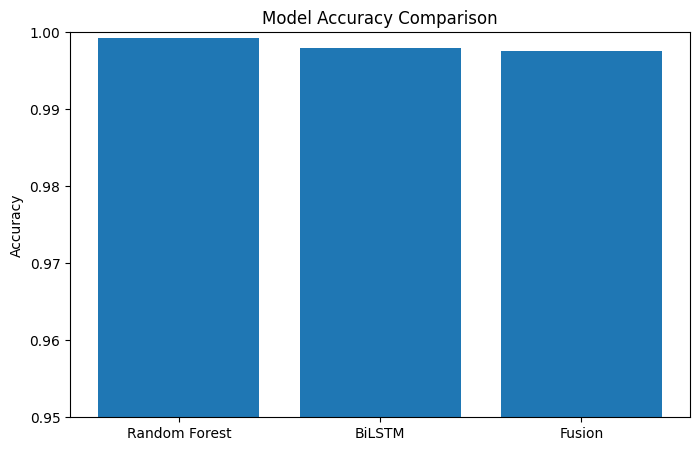

In [11]:
import matplotlib.pyplot as plt

models = ["Random Forest", "BiLSTM", "Fusion"]
accuracies = [rf_acc, bilstm_acc, fusion_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)
plt.show()

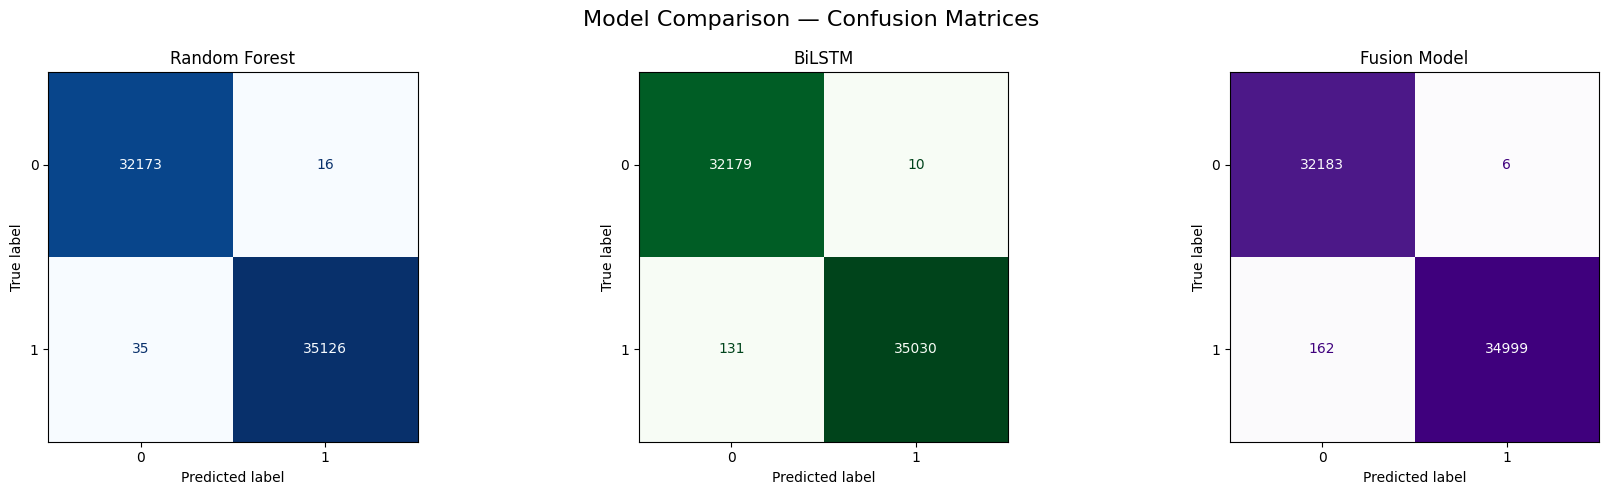

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrices
rf_cm = confusion_matrix(rf_true, rf_preds)
bilstm_cm = confusion_matrix(bilstm_true, bilstm_preds)
fusion_cm = confusion_matrix(rf_true, fusion_preds)

# Create subplot figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RF
ConfusionMatrixDisplay(rf_cm).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest")

# BiLSTM
ConfusionMatrixDisplay(bilstm_cm).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("BiLSTM")

# Fusion
ConfusionMatrixDisplay(fusion_cm).plot(ax=axes[2], cmap="Purples", colorbar=False)
axes[2].set_title("Fusion Model")

plt.suptitle("Model Comparison — Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Compute metrics
metrics = {
    "Model": ["Random Forest", "BiLSTM", "Fusion"],
    "Accuracy": [
        accuracy_score(rf_true, rf_preds),
        accuracy_score(bilstm_true, bilstm_preds),
        accuracy_score(rf_true, fusion_preds),
    ],
    "Precision": [
        precision_score(rf_true, rf_preds),
        precision_score(bilstm_true, bilstm_preds),
        precision_score(rf_true, fusion_preds),
    ],
    "Recall": [
        recall_score(rf_true, rf_preds),
        recall_score(bilstm_true, bilstm_preds),
        recall_score(rf_true, fusion_preds),
    ],
    "F1-score": [
        f1_score(rf_true, rf_preds),
        f1_score(bilstm_true, bilstm_preds),
        f1_score(rf_true, fusion_preds),
    ],
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.999243,0.999545,0.999005,0.999275
1,BiLSTM,0.997906,0.999715,0.996274,0.997991
2,Fusion,0.997506,0.999829,0.995393,0.997606


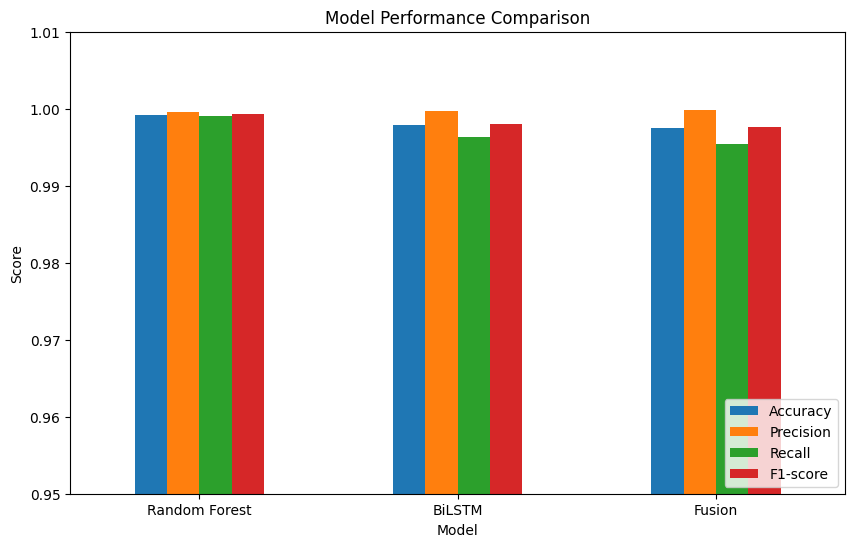

In [16]:
import matplotlib.pyplot as plt

# Set model names as index
df_plot = df_metrics.set_index("Model")

# Plot grouped bar chart
df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.95, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [19]:
# Save metrics table
df_metrics.to_csv("performance_metrics.csv", index=False)

print("Metrics table saved as performance_metrics.csv")

Metrics table saved as performance_metrics.csv


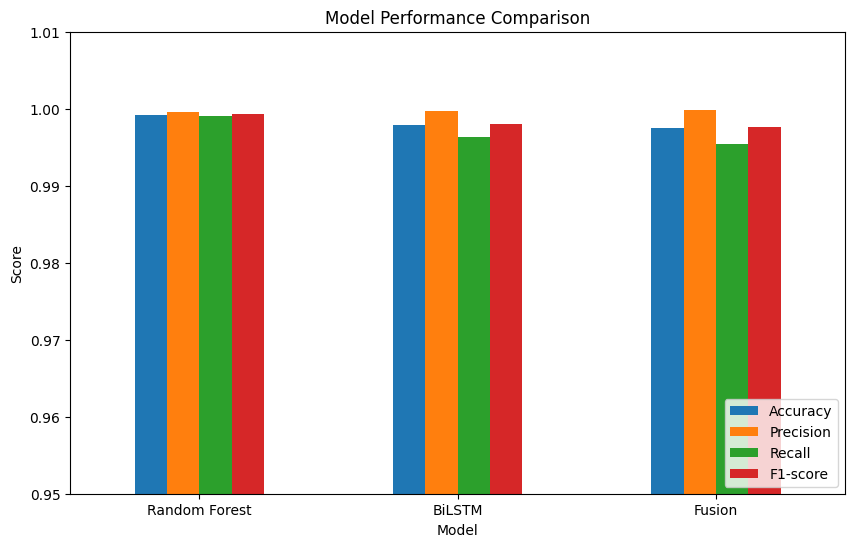

Performance chart saved as performance_chart.png


In [20]:
df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.95, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.savefig("performance_chart.png", dpi=300, bbox_inches="tight")
plt.show()

print("Performance chart saved as performance_chart.png")

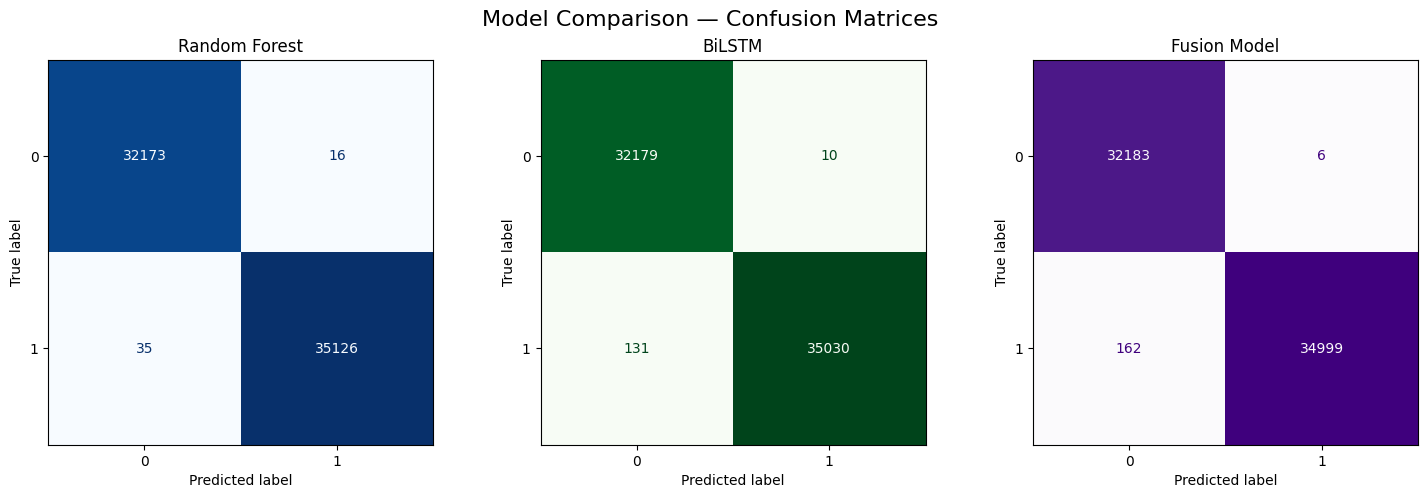

Confusion matrices saved as confusion_matrices.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(rf_cm).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(bilstm_cm).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("BiLSTM")

ConfusionMatrixDisplay(fusion_cm).plot(ax=axes[2], cmap="Purples", colorbar=False)
axes[2].set_title("Fusion Model")

plt.suptitle("Model Comparison — Confusion Matrices", fontsize=16)

plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrices saved as confusion_matrices.png")

In [23]:
!cp performance_metrics.csv /content/drive/MyDrive/
!cp performance_chart.png /content/drive/MyDrive/
!cp confusion_matrices.png /content/drive/MyDrive/

print("Files copied to Google Drive")

Files copied to Google Drive
